HEART DISEASE PREDICTION PIPELINE
EDA → SimCLR Self-Supervised Learning → Explainable AI

[1] Loading Dataset...
Dataset Shape: (1190, 12)
Total Samples: 1190
Features: 12

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1190 non-null   int64  
 1   sex                  1190 non-null   int64  
 2   chest pain type      1190 non-null   int64  
 3   resting bp s         1190 non-null   int64  
 4   cholesterol          1190 non-null   int64  
 5   fasting blood sugar  1190 non-null   int64  
 6   resting ecg          1190 non-null   int64  
 7   max heart rate       1190 non-null   int64  
 8   exercise angina      1190 non-null   int64  
 9   oldpeak              1190 non-null   float64
 10  ST slope             1190 non-null   int64  
 11  target               1190 non-null   int64  
dtypes

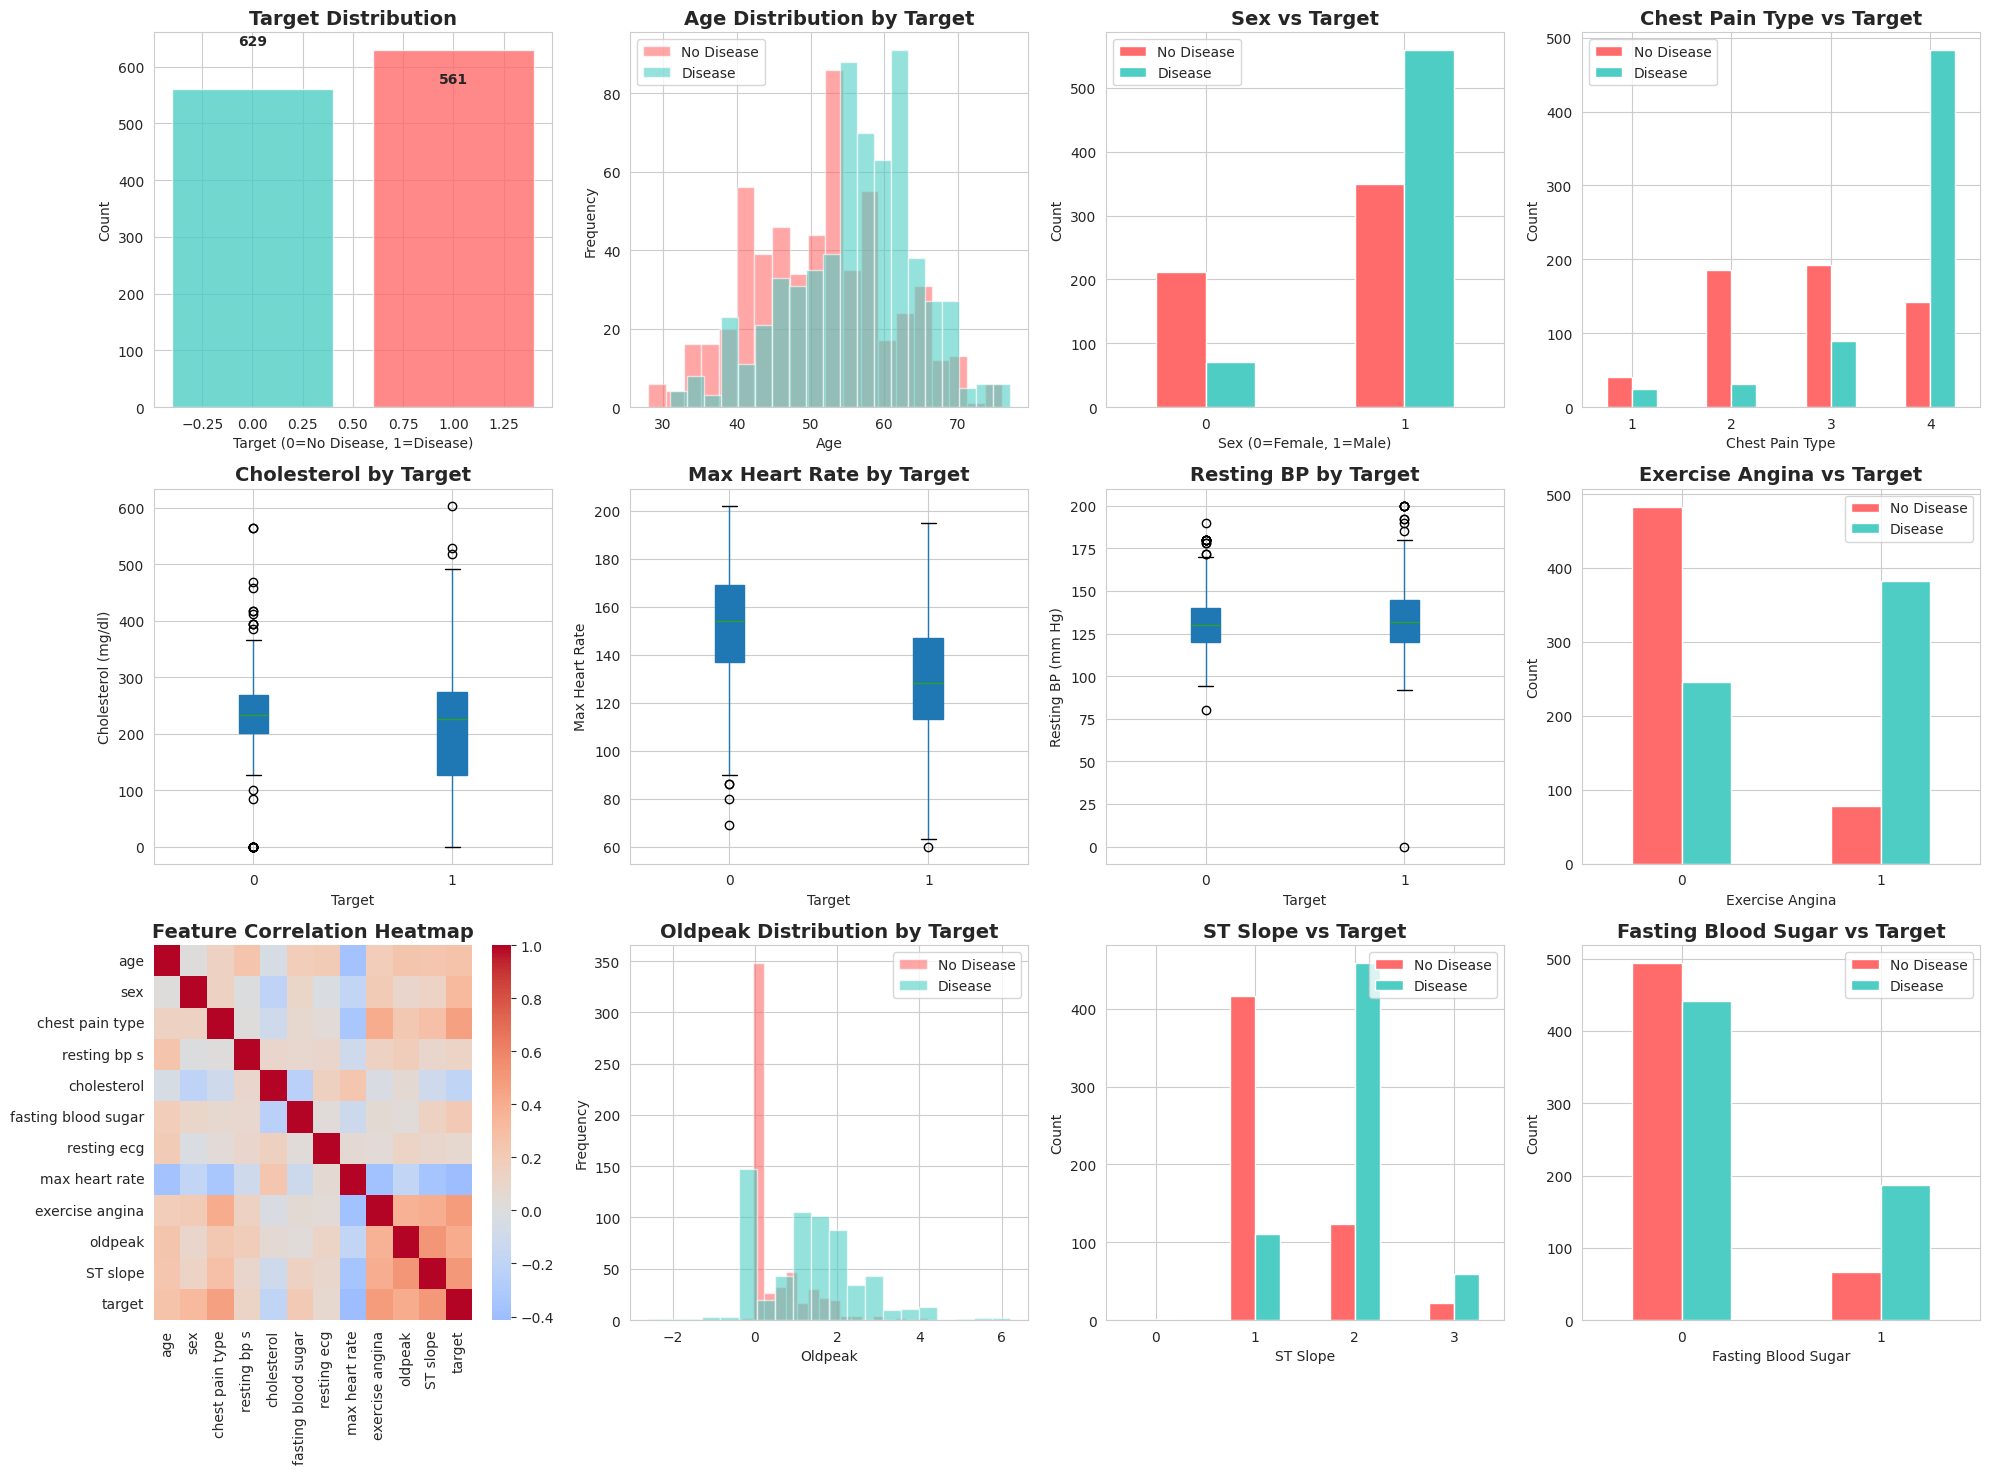


✓ EDA Visualization saved as 'eda_visualization.png'

Chi-Square Test for Categorical Features:
               Feature        Chi2       P-Value
5             ST slope  387.274681  1.263101e-83
1      chest pain type  334.418581  3.526191e-72
4      exercise angina  273.877675  1.621096e-61
0                  sex  113.832031  1.418278e-26
2  fasting blood sugar   54.824118  1.318133e-13
3          resting ecg   18.182304  1.126582e-04

[3] DATA PREPARATION
Features shape: (1190, 11)
Target shape: (1190,)

Training set: 952 samples
Test set: 238 samples

✓ Data preprocessing completed

[4] SIMCLR SELF-SUPERVISED LEARNING
Using device: cuda

Training SimCLR Encoder...
Epoch [10/50], Loss: 3.3120
Epoch [20/50], Loss: 3.2438
Epoch [30/50], Loss: 3.1897
Epoch [40/50], Loss: 3.1635
Epoch [50/50], Loss: 3.1532

✓ SimCLR training completed


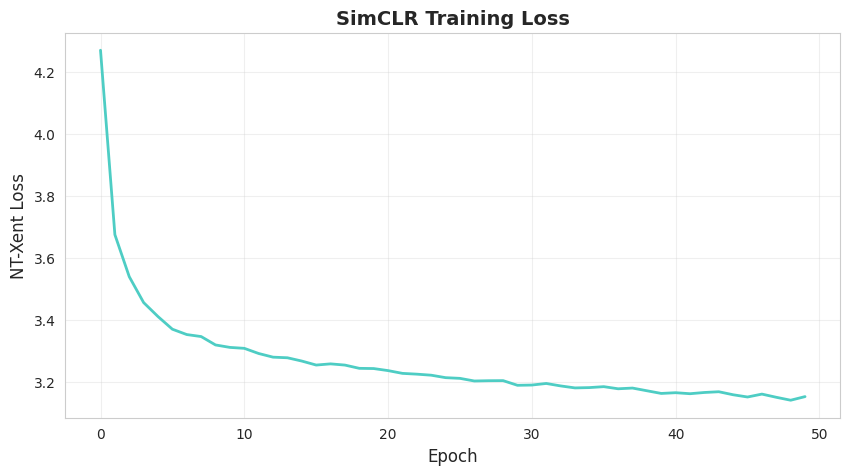


[5] FINE-TUNING CLASSIFIER

Training classifier...
Epoch [20/100] - Train Acc: 87.82%, Test Acc: 89.50%
Epoch [40/100] - Train Acc: 88.24%, Test Acc: 89.92%
Epoch [60/100] - Train Acc: 89.39%, Test Acc: 90.34%
Epoch [80/100] - Train Acc: 91.49%, Test Acc: 90.34%
Epoch [100/100] - Train Acc: 92.54%, Test Acc: 90.76%

✓ Classifier training completed


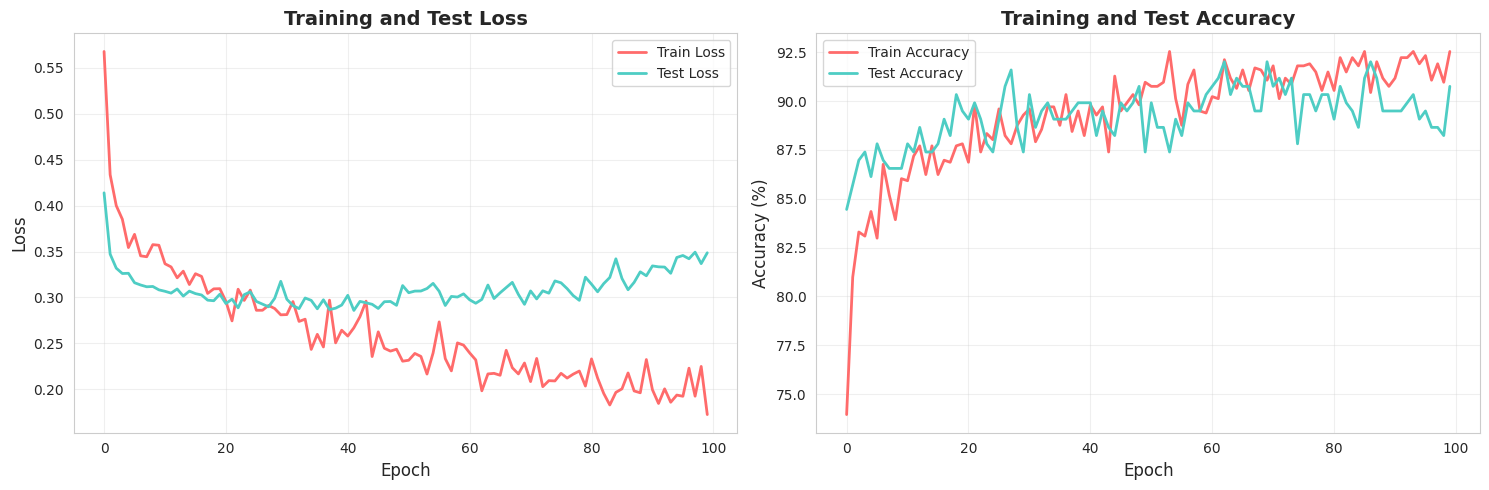


[6] MODEL EVALUATION

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.91      0.89      0.90       112
     Disease       0.91      0.92      0.91       126

    accuracy                           0.91       238
   macro avg       0.91      0.91      0.91       238
weighted avg       0.91      0.91      0.91       238



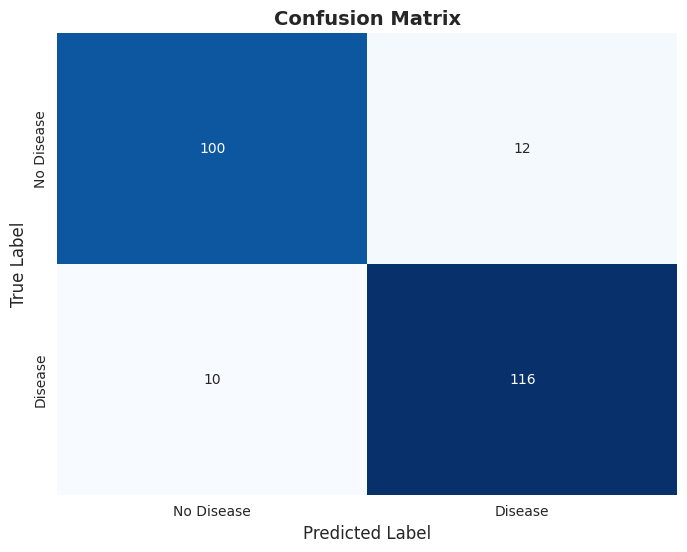

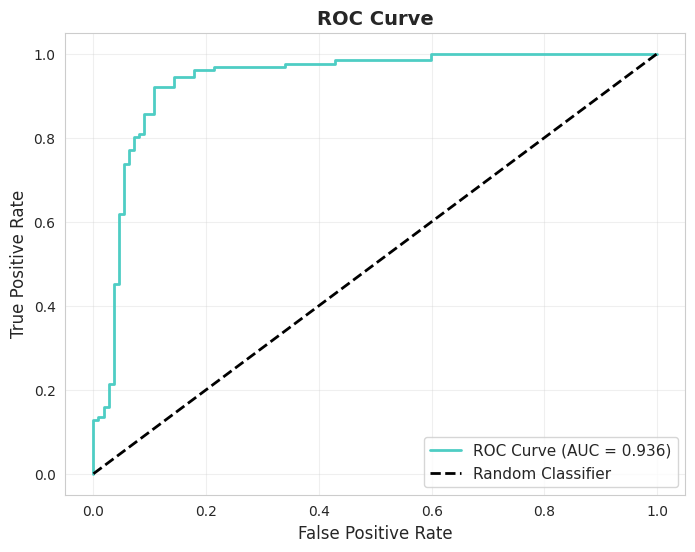


✓ ROC-AUC Score: 0.9362

[7] EXPLAINABLE AI - SHAP Analysis

Calculating SHAP values (this may take a few minutes)...


  0%|          | 0/100 [00:00<?, ?it/s]


✓ SHAP analysis completed


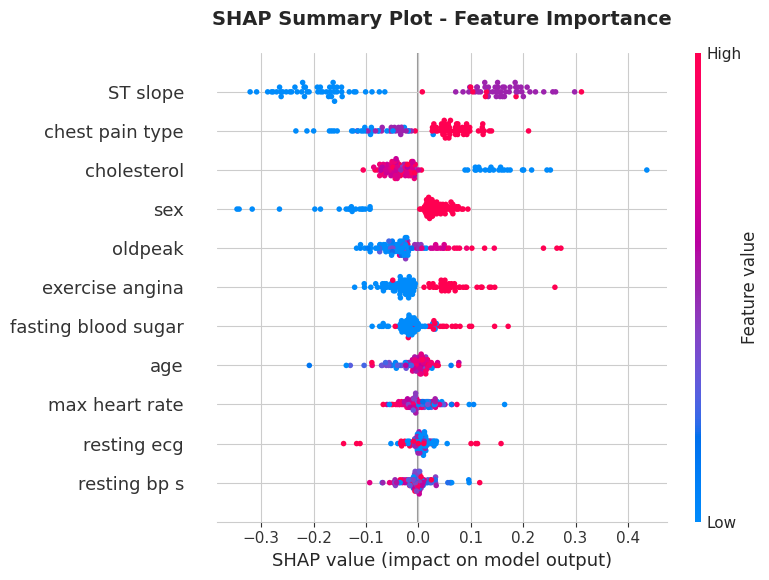

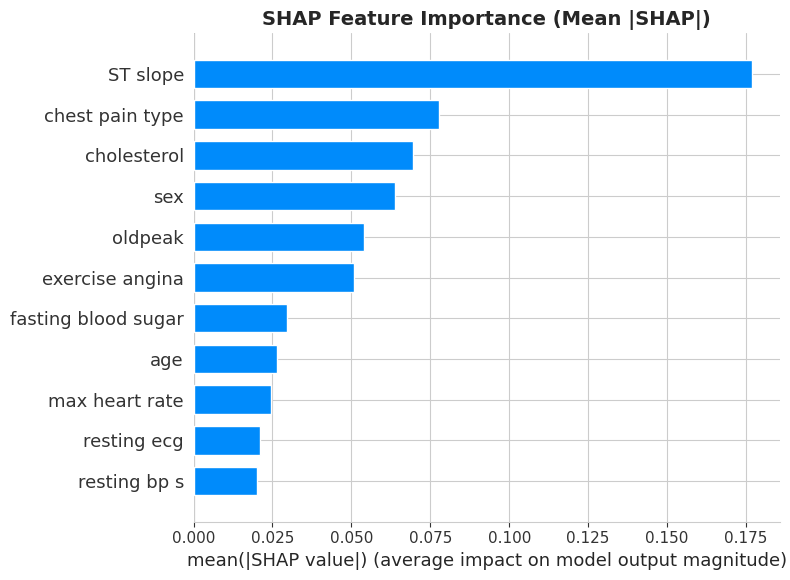

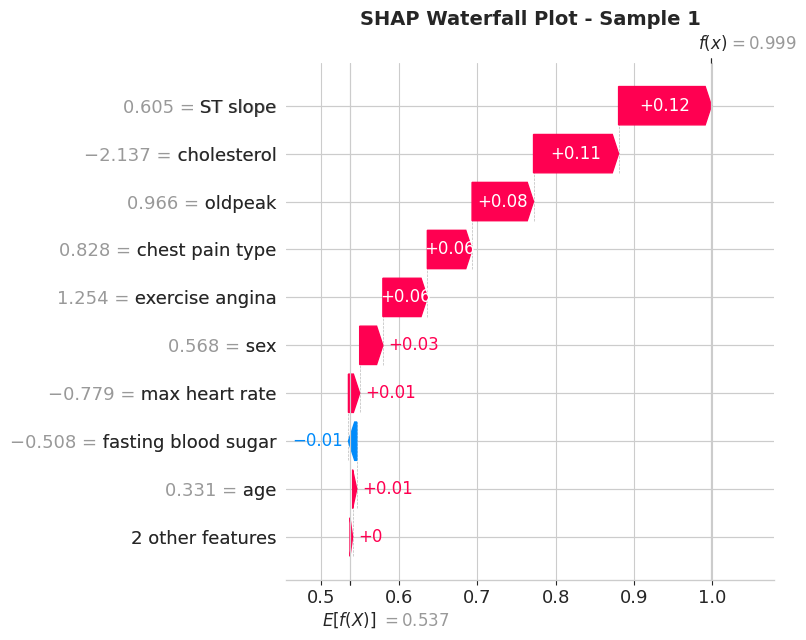


Feature Importance Ranking (SHAP):
                Feature  Importance
10             ST slope    0.176952
2       chest pain type    0.077679
4           cholesterol    0.069648
1                   sex    0.063778
9               oldpeak    0.053858
8       exercise angina    0.050739
5   fasting blood sugar    0.029463
0                   age    0.026478
7        max heart rate    0.024660
6           resting ecg    0.020913
3          resting bp s    0.020210

PIPELINE COMPLETED SUCCESSFULLY!

📊 Generated Visualizations:
  1. eda_visualization.png - Comprehensive EDA
  2. simclr_loss.png - SimCLR training loss
  3. training_history.png - Model training metrics
  4. confusion_matrix.png - Confusion matrix
  5. roc_curve.png - ROC curve
  6. shap_summary.png - SHAP summary plot
  7. shap_importance.png - SHAP feature importance
  8. shap_waterfall.png - Individual prediction explanation

🎯 Final Model Performance:
  • Test Accuracy: 90.76%
  • ROC-AUC Score: 0.9362
  • Total Samples:

In [1]:
# Heart Disease Prediction: EDA → SimCLR → Explainable AI
# Complete Pipeline for Kaggle Environment

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

# Deep Learning Libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

# For Explainable AI
import shap
from scipy.stats import chi2_contingency

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("=" * 80)
print("HEART DISEASE PREDICTION PIPELINE")
print("EDA → SimCLR Self-Supervised Learning → Explainable AI")
print("=" * 80)

# ============================================================================
# PART 1: DATA LOADING & PREPROCESSING
# ============================================================================

print("\n[1] Loading Dataset...")
df = pd.read_csv('/kaggle/input/heart-disease-dataset/heart_statlog_cleveland_hungary_final.csv')

print(f"Dataset Shape: {df.shape}")
print(f"Total Samples: {df.shape[0]}")
print(f"Features: {df.shape[1]}")

# Basic info
print("\nDataset Info:")
print(df.info())

print("\nFirst 5 rows:")
print(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTarget Distribution:")
print(df['target'].value_counts())

# ============================================================================
# PART 2: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================================

print("\n" + "=" * 80)
print("[2] EXPLORATORY DATA ANALYSIS")
print("=" * 80)

# Statistical Summary
print("\nStatistical Summary:")
print(df.describe())

# Create figure for EDA
fig = plt.figure(figsize=(20, 15))

# 1. Target Distribution
ax1 = plt.subplot(3, 4, 1)
target_counts = df['target'].value_counts()
colors = ['#FF6B6B', '#4ECDC4']
plt.bar(target_counts.index, target_counts.values, color=colors, alpha=0.8)
plt.title('Target Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Target (0=No Disease, 1=Disease)')
plt.ylabel('Count')
for i, v in enumerate(target_counts.values):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')

# 2. Age Distribution by Target
ax2 = plt.subplot(3, 4, 2)
df[df['target']==0]['age'].hist(bins=20, alpha=0.6, label='No Disease', color='#FF6B6B')
df[df['target']==1]['age'].hist(bins=20, alpha=0.6, label='Disease', color='#4ECDC4')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution by Target', fontsize=14, fontweight='bold')
plt.legend()

# 3. Sex Distribution
ax3 = plt.subplot(3, 4, 3)
sex_target = pd.crosstab(df['sex'], df['target'])
sex_target.plot(kind='bar', ax=ax3, color=['#FF6B6B', '#4ECDC4'])
plt.title('Sex vs Target', fontsize=14, fontweight='bold')
plt.xlabel('Sex (0=Female, 1=Male)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(['No Disease', 'Disease'])

# 4. Chest Pain Type Distribution
ax4 = plt.subplot(3, 4, 4)
cp_target = pd.crosstab(df['chest pain type'], df['target'])
cp_target.plot(kind='bar', ax=ax4, color=['#FF6B6B', '#4ECDC4'])
plt.title('Chest Pain Type vs Target', fontsize=14, fontweight='bold')
plt.xlabel('Chest Pain Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(['No Disease', 'Disease'])

# 5. Cholesterol Distribution
ax5 = plt.subplot(3, 4, 5)
df.boxplot(column='cholesterol', by='target', ax=ax5, patch_artist=True)
plt.title('Cholesterol by Target', fontsize=14, fontweight='bold')
plt.suptitle('')
plt.xlabel('Target')
plt.ylabel('Cholesterol (mg/dl)')

# 6. Max Heart Rate Distribution
ax6 = plt.subplot(3, 4, 6)
df.boxplot(column='max heart rate', by='target', ax=ax6, patch_artist=True)
plt.title('Max Heart Rate by Target', fontsize=14, fontweight='bold')
plt.suptitle('')
plt.xlabel('Target')
plt.ylabel('Max Heart Rate')

# 7. Resting BP Distribution
ax7 = plt.subplot(3, 4, 7)
df.boxplot(column='resting bp s', by='target', ax=ax7, patch_artist=True)
plt.title('Resting BP by Target', fontsize=14, fontweight='bold')
plt.suptitle('')
plt.xlabel('Target')
plt.ylabel('Resting BP (mm Hg)')

# 8. Exercise Angina
ax8 = plt.subplot(3, 4, 8)
angina_target = pd.crosstab(df['exercise angina'], df['target'])
angina_target.plot(kind='bar', ax=ax8, color=['#FF6B6B', '#4ECDC4'])
plt.title('Exercise Angina vs Target', fontsize=14, fontweight='bold')
plt.xlabel('Exercise Angina')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(['No Disease', 'Disease'])

# 9. Correlation Heatmap
ax9 = plt.subplot(3, 4, 9)
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, ax=ax9)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')

# 10. Oldpeak Distribution
ax10 = plt.subplot(3, 4, 10)
df[df['target']==0]['oldpeak'].hist(bins=20, alpha=0.6, label='No Disease', color='#FF6B6B')
df[df['target']==1]['oldpeak'].hist(bins=20, alpha=0.6, label='Disease', color='#4ECDC4')
plt.xlabel('Oldpeak')
plt.ylabel('Frequency')
plt.title('Oldpeak Distribution by Target', fontsize=14, fontweight='bold')
plt.legend()

# 11. ST Slope Distribution
ax11 = plt.subplot(3, 4, 11)
st_target = pd.crosstab(df['ST slope'], df['target'])
st_target.plot(kind='bar', ax=ax11, color=['#FF6B6B', '#4ECDC4'])
plt.title('ST Slope vs Target', fontsize=14, fontweight='bold')
plt.xlabel('ST Slope')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(['No Disease', 'Disease'])

# 12. Fasting Blood Sugar
ax12 = plt.subplot(3, 4, 12)
fbs_target = pd.crosstab(df['fasting blood sugar'], df['target'])
fbs_target.plot(kind='bar', ax=ax12, color=['#FF6B6B', '#4ECDC4'])
plt.title('Fasting Blood Sugar vs Target', fontsize=14, fontweight='bold')
plt.xlabel('Fasting Blood Sugar')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(['No Disease', 'Disease'])

plt.tight_layout()
plt.savefig('eda_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ EDA Visualization saved as 'eda_visualization.png'")

# Feature Importance using Chi-Square Test for Categorical Variables
print("\nChi-Square Test for Categorical Features:")
categorical_features = ['sex', 'chest pain type', 'fasting blood sugar', 
                        'resting ecg', 'exercise angina', 'ST slope']

chi_results = []
for feature in categorical_features:
    contingency_table = pd.crosstab(df[feature], df['target'])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    chi_results.append({'Feature': feature, 'Chi2': chi2, 'P-Value': p_value})
    
chi_df = pd.DataFrame(chi_results).sort_values('Chi2', ascending=False)
print(chi_df)

# ============================================================================
# PART 3: DATA PREPARATION FOR SIMCLR
# ============================================================================

print("\n" + "=" * 80)
print("[3] DATA PREPARATION")
print("=" * 80)

# Prepare features and target
X = df.drop('target', axis=1).values
y = df['target'].values

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✓ Data preprocessing completed")

# ============================================================================
# PART 4: SIMCLR SELF-SUPERVISED LEARNING
# ============================================================================

print("\n" + "=" * 80)
print("[4] SIMCLR SELF-SUPERVISED LEARNING")
print("=" * 80)

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Custom Dataset for SimCLR
class HeartDataset(Dataset):
    def __init__(self, X, y=None, augment=False):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y) if y is not None else None
        self.augment = augment
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        x = self.X[idx]
        
        if self.augment:
            # Data augmentation: add Gaussian noise and scaling
            x1 = x + torch.randn_like(x) * 0.1
            x2 = x * (1 + torch.randn(1) * 0.1)
            
            if self.y is not None:
                return x1, x2, self.y[idx]
            return x1, x2
        
        if self.y is not None:
            return x, self.y[idx]
        return x

# SimCLR Encoder Network
class SimCLREncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, projection_dim=64):
        super(SimCLREncoder, self).__init__()
        
        # Encoder (Backbone)
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU()
        )
        
        # Projection Head
        self.projection = nn.Sequential(
            nn.Linear(hidden_dim // 2, projection_dim),
            nn.ReLU(),
            nn.Linear(projection_dim, projection_dim)
        )
    
    def forward(self, x):
        h = self.encoder(x)
        z = self.projection(h)
        return h, z

# NT-Xent Loss (Normalized Temperature-scaled Cross Entropy Loss)
class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.5):
        super(NTXentLoss, self).__init__()
        self.temperature = temperature
    
    def forward(self, z_i, z_j):
        batch_size = z_i.shape[0]
        
        # Normalize embeddings
        z_i = F.normalize(z_i, dim=1)
        z_j = F.normalize(z_j, dim=1)
        
        # Concatenate
        z = torch.cat([z_i, z_j], dim=0)
        
        # Compute similarity matrix
        sim_matrix = torch.mm(z, z.t()) / self.temperature
        
        # Create positive pairs mask
        mask = torch.eye(2 * batch_size, dtype=torch.bool, device=z.device)
        sim_matrix = sim_matrix.masked_fill(mask, -9e15)
        
        # Positive pairs: diagonal elements
        pos_sim = torch.cat([
            torch.diag(sim_matrix, batch_size),
            torch.diag(sim_matrix, -batch_size)
        ])
        
        # Compute loss
        loss = -pos_sim + torch.logsumexp(sim_matrix, dim=1)
        loss = loss.mean()
        
        return loss

# Classifier on top of encoder
class HeartClassifier(nn.Module):
    def __init__(self, encoder, hidden_dim=64):
        super(HeartClassifier, self).__init__()
        self.encoder = encoder.encoder
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 2)
        )
    
    def forward(self, x):
        h = self.encoder(x)
        out = self.classifier(h)
        return out

# Training SimCLR
print("\nTraining SimCLR Encoder...")

input_dim = X_train_scaled.shape[1]
simclr_model = SimCLREncoder(input_dim=input_dim).to(device)
criterion_simclr = NTXentLoss(temperature=0.5)
optimizer_simclr = optim.Adam(simclr_model.parameters(), lr=0.001)

# Create DataLoader for SimCLR
train_dataset_simclr = HeartDataset(X_train_scaled, y_train, augment=True)
train_loader_simclr = DataLoader(train_dataset_simclr, batch_size=64, shuffle=True)

num_epochs_simclr = 50
simclr_losses = []

for epoch in range(num_epochs_simclr):
    simclr_model.train()
    epoch_loss = 0
    
    for x1, x2, _ in train_loader_simclr:
        x1, x2 = x1.to(device), x2.to(device)
        
        optimizer_simclr.zero_grad()
        
        _, z1 = simclr_model(x1)
        _, z2 = simclr_model(x2)
        
        loss = criterion_simclr(z1, z2)
        loss.backward()
        optimizer_simclr.step()
        
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_loader_simclr)
    simclr_losses.append(avg_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs_simclr}], Loss: {avg_loss:.4f}")

print("\n✓ SimCLR training completed")

# Plot SimCLR training loss
plt.figure(figsize=(10, 5))
plt.plot(simclr_losses, linewidth=2, color='#4ECDC4')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('NT-Xent Loss', fontsize=12)
plt.title('SimCLR Training Loss', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.savefig('simclr_loss.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# PART 5: FINE-TUNING CLASSIFIER
# ============================================================================

print("\n" + "=" * 80)
print("[5] FINE-TUNING CLASSIFIER")
print("=" * 80)

# Create classifier with pretrained encoder
classifier = HeartClassifier(simclr_model, hidden_dim=64).to(device)

# Prepare data loaders
train_dataset = HeartDataset(X_train_scaled, y_train)
test_dataset = HeartDataset(X_test_scaled, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Training setup
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(classifier.parameters(), lr=0.001)

num_epochs = 100
train_losses = []
test_losses = []
train_accs = []
test_accs = []

print("\nTraining classifier...")

for epoch in range(num_epochs):
    # Training
    classifier.train()
    train_loss = 0
    train_correct = 0
    train_total = 0
    
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        
        optimizer.zero_grad()
        outputs = classifier(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        train_total += y.size(0)
        train_correct += predicted.eq(y).sum().item()
    
    # Testing
    classifier.eval()
    test_loss = 0
    test_correct = 0
    test_total = 0
    
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            outputs = classifier(x)
            loss = criterion(outputs, y)
            
            test_loss += loss.item()
            _, predicted = outputs.max(1)
            test_total += y.size(0)
            test_correct += predicted.eq(y).sum().item()
    
    train_acc = 100. * train_correct / train_total
    test_acc = 100. * test_correct / test_total
    
    train_losses.append(train_loss / len(train_loader))
    test_losses.append(test_loss / len(test_loader))
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] - Train Acc: {train_acc:.2f}%, Test Acc: {test_acc:.2f}%")

print("\n✓ Classifier training completed")

# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(train_losses, label='Train Loss', linewidth=2, color='#FF6B6B')
ax1.plot(test_losses, label='Test Loss', linewidth=2, color='#4ECDC4')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training and Test Loss', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(train_accs, label='Train Accuracy', linewidth=2, color='#FF6B6B')
ax2.plot(test_accs, label='Test Accuracy', linewidth=2, color='#4ECDC4')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Training and Test Accuracy', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# PART 6: MODEL EVALUATION
# ============================================================================

print("\n" + "=" * 80)
print("[6] MODEL EVALUATION")
print("=" * 80)

classifier.eval()
all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        outputs = classifier(x)
        probs = F.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(y.numpy())

all_preds = np.array(all_preds)
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# Classification Report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, 
                          target_names=['No Disease', 'Disease']))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xticks([0.5, 1.5], ['No Disease', 'Disease'])
plt.yticks([0.5, 1.5], ['No Disease', 'Disease'])
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(all_labels, all_probs[:, 1])
roc_auc = roc_auc_score(all_labels, all_probs[:, 1])

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC = {roc_auc:.3f})', color='#4ECDC4')
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ ROC-AUC Score: {roc_auc:.4f}")

# ============================================================================
# PART 7: EXPLAINABLE AI (SHAP)
# ============================================================================

print("\n" + "=" * 80)
print("[7] EXPLAINABLE AI - SHAP Analysis")
print("=" * 80)

# Wrapper function for SHAP
def model_predict(x):
    classifier.eval()
    with torch.no_grad():
        x_tensor = torch.FloatTensor(x).to(device)
        outputs = classifier(x_tensor)
        probs = F.softmax(outputs, dim=1)
    return probs.cpu().numpy()

# Create SHAP explainer
print("\nCalculating SHAP values (this may take a few minutes)...")

# Use a subset for SHAP to speed up computation
sample_size = min(100, len(X_test_scaled))
X_test_sample = X_test_scaled[:sample_size]

explainer = shap.KernelExplainer(model_predict, X_train_scaled[:100])
shap_values = explainer.shap_values(X_test_sample)

# Get feature names
feature_names = ['age', 'sex', 'chest pain type', 'resting bp s', 'cholesterol',
                'fasting blood sugar', 'resting ecg', 'max heart rate',
                'exercise angina', 'oldpeak', 'ST slope']

print("\n✓ SHAP analysis completed")

# SHAP Summary Plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values[1], X_test_sample, feature_names=feature_names, 
                 show=False, plot_type='dot')
plt.title('SHAP Summary Plot - Feature Importance', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()

# SHAP Bar Plot - Mean Absolute SHAP values
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values[1], X_test_sample, feature_names=feature_names,
                 plot_type='bar', show=False)
plt.title('SHAP Feature Importance (Mean |SHAP|)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# Individual prediction explanation (first test sample)
sample_idx = 0
plt.figure(figsize=(12, 6))
shap.waterfall_plot(shap.Explanation(
    values=shap_values[1][sample_idx],
    base_values=explainer.expected_value[1],
    data=X_test_sample[sample_idx],
    feature_names=feature_names
), show=False)
plt.title(f'SHAP Waterfall Plot - Sample {sample_idx+1}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=300, bbox_inches='tight')
plt.show()

# Feature importance ranking
mean_abs_shap = np.abs(shap_values[1]).mean(axis=0)
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': mean_abs_shap
}).sort_values('Importance', ascending=False)

print("\nFeature Importance Ranking (SHAP):")
print(importance_df)

# ============================================================================
# FINAL SUMMARY
# ============================================================================

print("\n" + "=" * 80)
print("PIPELINE COMPLETED SUCCESSFULLY!")
print("=" * 80)

print("\n📊 Generated Visualizations:")
print("  1. eda_visualization.png - Comprehensive EDA")
print("  2. simclr_loss.png - SimCLR training loss")
print("  3. training_history.png - Model training metrics")
print("  4. confusion_matrix.png - Confusion matrix")
print("  5. roc_curve.png - ROC curve")
print("  6. shap_summary.png - SHAP summary plot")
print("  7. shap_importance.png - SHAP feature importance")
print("  8. shap_waterfall.png - Individual prediction explanation")

print("\n🎯 Final Model Performance:")
print(f"  • Test Accuracy: {test_accs[-1]:.2f}%")
print(f"  • ROC-AUC Score: {roc_auc:.4f}")
print(f"  • Total Samples: {len(df)}")
print(f"  • Training Samples: {len(X_train)}")
print(f"  • Test Samples: {len(X_test)}")

print("\n🔍 Top 3 Most Important Features (SHAP):")
for idx, row in importance_df.head(3).iterrows():
    print(f"  {idx+1}. {row['Feature']}: {row['Importance']:.4f}")

print("\n✨ All Done! Your complete heart disease prediction pipeline is ready.")
print("=" * 80)